In [3]:
# -------------------------
# 1. Imports
# -------------------------
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# 2. Load Dataset
# -------------------------
# Load your cleaned dataset (update path as per your folder)
df = pd.read_csv("data/cleaned/emotion_clean_final_filtered.csv")

print("Original Emotion Labels:", df['label'].unique())
print("Shape:", df.shape)

# -------------------------
# 3. Define Mapping
# -------------------------
# Example mapping: you can adjust depending on your mentor’s advice
emotion_map = {
    "afraid": "fear",
    "anxious": "fear",
    "apprehensive": "fear",
    "terrified": "fear",

    "angry": "anger",
    "furious": "anger",
    "disgusted": "anger",

    "joyful": "joy",
    "hopeful": "joy",
    "proud": "joy",
    "impressed": "joy",
    "grateful": "joy",
    "content": "joy",
    "nostalgic": "joy",

    "sad": "sadness",
    "devastated": "sadness",
    "disappointed": "sadness",
    "lonely": "sadness",
    "embarrassed": "sadness",
    "ashamed": "sadness",
    "guilty": "sadness",

    "faithful": "trust",
    "trusting": "trust",
    "caring": "trust",
    "sentimental": "trust",

    "surprised": "surprise"
}

# Apply mapping
df["mapped_label"] = df["label"].map(emotion_map)

print("Mapped Emotion Labels:", df["mapped_label"].unique())
print(df.head())




Original Emotion Labels: ['sentimental' 'afraid' 'proud' 'faithful' 'terrified' 'joyful' 'angry'
 'sad' 'grateful' 'prepared' 'embarrassed' 'lonely' 'ashamed' 'guilty'
 'surprised' 'nostalgic' 'confident' 'furious' 'disappointed' 'caring'
 'trusting' 'disgusted' 'anxious' 'hopeful' 'content' 'impressed'
 'apprehensive' 'devastated']
Shape: (54844, 2)
Mapped Emotion Labels: ['trust' 'fear' 'joy' 'anger' 'sadness' nan 'surprise']
                                                text        label mapped_label
0  I remember going to see the fireworks with my ...  sentimental        trust
1              This was a best friend . I miss her .  sentimental        trust
2                                We no longer talk .  sentimental        trust
3  Was this a friend you were in love with , or j...  sentimental        trust
4                               Where has she gone ?  sentimental        trust


In [6]:
from collections import Counter
import numpy as np

# Vectorize again
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X = vectorizer.fit_transform(df["text"])
words = np.array(vectorizer.get_feature_names_out())

# Compute most frequent words per label
for label in df["label"].unique():
    text = " ".join(df[df["label"] == label]["text"])
    common = Counter(text.split()).most_common(10)
    print(f"{label}: {common}")


sentimental: [('.', 1750), ('I', 1304), ('to', 654), ('a', 623), (',', 586), ('my', 539), ('the', 467), ('and', 452), ('it', 425), ('of', 413)]
afraid: [('.', 1865), ('I', 1631), ('to', 780), ('the', 732), ('a', 721), ('was', 714), (',', 683), ('it', 527), ('?', 508), ('and', 499)]
proud: [('.', 1745), ('I', 1150), ('!', 884), ('to', 691), ('a', 686), (',', 622), ('the', 538), ('and', 469), ('is', 465), ('was', 431)]
faithful: [('.', 1187), ('I', 956), ('to', 578), (',', 514), ('a', 486), ('you', 341), ('my', 336), ('the', 322), ('and', 317), ('!', 258)]
terrified: [('.', 1850), ('I', 1699), ('a', 793), ('was', 761), ('the', 741), (',', 709), ('to', 695), ('!', 573), ('and', 538), ('it', 532)]
joyful: [('.', 1438), ('I', 1231), ('!', 778), (',', 706), ('to', 693), ('a', 653), ('the', 613), ('you', 442), ('was', 424), ('and', 415)]
angry: [('.', 2069), ('I', 1511), ('to', 871), (',', 736), ('the', 715), ('my', 632), ('a', 627), ('it', 599), ('and', 580), ('was', 539)]
sad: [('.', 2341),

In [8]:
from collections import Counter, defaultdict

bias_candidates = defaultdict(list)

for label in df["label"].unique():
    text = " ".join(df[df["label"] == label]["text"])
    counts = Counter(text.split())
    
    # take top 20 non-stopwords for each label
    common = [w for w, c in counts.most_common(50) if w not in ["i", "the", "a", "to", "and", "it", ".", ",", "was", "you", "my"]]
    bias_candidates[label] = common[:20]

for label, words in bias_candidates.items():
    print(label, ":", words)


sentimental : ['I', 'of', '?', 'that', 'is', 'me', 'so', '!', 'have', 'old', 'in', 'when', 'for', 'It', 'with', 'are', 'really', 'her', 'they', 'about']
afraid : ['I', '?', '!', 'in', 'of', 'that', 'me', 'so', 'have', 'is', 'scared', 'but', 'for', 'am', 'be', 'out', 'not', 'at', 'on', 'just']
proud : ['I', '!', 'is', 'of', 'so', '?', 'for', 'that', 'in', 'My', 'he', 'am', 'proud', 'be', 'really', 'happy', 'with', 'her', 'did', 'have']
faithful : ['I', '!', 'that', '?', 'have', 'for', 'is', 'of', 'in', 'me', 'on', 'but', 'so', 'with', 'be', 'good', 'been', 'do', 'her', 'are']
terrified : ['I', '!', '?', 'of', 'in', 'that', 'so', 'me', 'scared', 'is', 'have', 'am', 'out', 'on', 'for', 'scary', 'It', 'Oh', 'at', 'but']
joyful : ['I', '!', '?', 'is', 'so', 'for', 'of', 'happy', 'that', 'have', 'in', 'am', 'with', 'It', 'are', 'be', 'got', 'great', 'on', "I'm"]
angry : ['I', '?', '!', 'that', 'me', 'so', 'is', 'of', 'in', 'they', 'for', 'have', 'at', 'on', 'he', 'when', 'but', 'not', 'did',

In [9]:
bias_words = [
    # Emotion synonyms
    "proud", "happy", "guilty", "ashamed", "nervous", "scared", "scary",
    "gross", "hope", "memories", "old", "back", "sorry",
    "embarrassed", "furious",

    # Generic intensifiers that confuse
    "oh", "no", "really", "so", "just", "very"
]


In [11]:
import re

def remove_bias_words(text, bias_words):
    pattern = r"\b(" + "|".join(map(re.escape, bias_words)) + r")\b"
    return re.sub(pattern, "", text)

df["clean_text"] = df["text"].apply(lambda x: remove_bias_words(x, bias_words))


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# TF-IDF with bias words removed
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X = vectorizer.fit_transform(df["clean_text"])

# Cluster
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df["cluster_nobias"] = kmeans.fit_predict(X)

print(df.groupby("cluster_nobias")["label"].value_counts().head(20))


cluster_nobias  label       
0               hopeful         128
                confident       109
                prepared         99
                apprehensive     91
                afraid           83
                nostalgic        82
                sad              82
                anxious          76
                guilty           76
                terrified        75
                angry            71
                surprised        69
                sentimental      68
                content          57
                lonely           53
                disgusted        52
                trusting         51
                embarrassed      50
                disappointed     46
                faithful         46
Name: count, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label"], test_size=0.2, random_state=42
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LinearSVC()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

      afraid       0.14      0.18      0.16       387
       angry       0.20      0.16      0.18       467
     anxious       0.27      0.24      0.26       413
apprehensive       0.18      0.12      0.14       313
     ashamed       0.17      0.11      0.13       341
      caring       0.28      0.33      0.30       315
   confident       0.21      0.27      0.24       362
     content       0.30      0.33      0.31       371
  devastated       0.21      0.19      0.20       350
disappointed       0.24      0.23      0.23       373
   disgusted       0.42      0.41      0.41       409
 embarrassed       0.36      0.45      0.40       359
    faithful       0.31      0.25      0.28       253
     furious       0.18      0.17      0.18       393
    grateful       0.25      0.25      0.25       420
      guilty       0.26      0.30      0.28       390
     hopeful       0.29      0.23      0.26       440
   impressed       0.25    

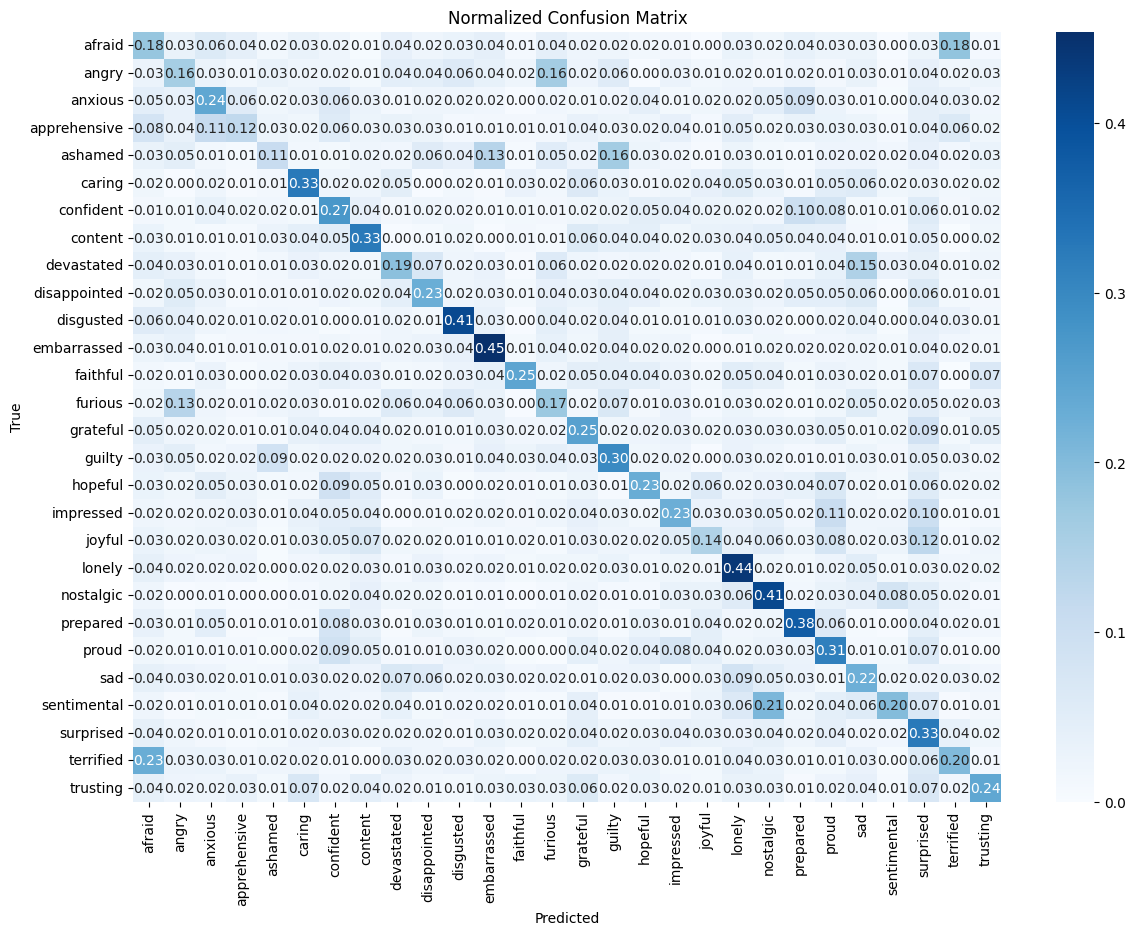

In [16]:
import numpy as np

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 10))
sns.heatmap(cm_normalized, annot=True, fmt=".2f", cmap="Blues", 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Normalized Confusion Matrix")
plt.show()


In [26]:
# -------------------------
# 1. Imports
# -------------------------
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# 2. Load Dataset
# -------------------------
# Load your cleaned dataset (update path as per your folder)
df = pd.read_csv("data/cleaned/emotion_clean_final_filtered.csv")

print("Original Emotion Labels:", df['label'].unique())
print("Shape:", df.shape)

df = df.dropna(subset=["text", "label"])
# -------------------------
# 3. Define Mapping
# -------------------------
# Example mapping: you can adjust depending on your mentor’s advice
emotion_map = {
    "afraid": "fear",
    "anxious": "fear",
    "apprehensive": "fear",
    "terrified": "fear",

    "angry": "anger",
    "furious": "anger",
    "disgusted": "anger",

    "joyful": "joy",
    "hopeful": "joy",
    "proud": "joy",
    "impressed": "joy",
    "grateful": "joy",
    "content": "joy",
    "nostalgic": "joy",

    "sad": "sadness",
    "devastated": "sadness",
    "disappointed": "sadness",
    "lonely": "sadness",
    "embarrassed": "sadness",
    "ashamed": "sadness",
    "guilty": "sadness",

    "faithful": "trust",
    "trusting": "trust",
    "caring": "trust",
    "sentimental": "trust",

    "surprised": "surprise"
}

# Apply mapping
df["label_mapped"] = df["label"].map(emotion_map).fillna(df["label"])

# Drop rows where mapped label is missing
df = df.dropna(subset=["label_mapped"])
print("Mapped Emotion Labels:", df["label_mapped"].unique())
print(df.head())

# -------------------------



Original Emotion Labels: ['sentimental' 'afraid' 'proud' 'faithful' 'terrified' 'joyful' 'angry'
 'sad' 'grateful' 'prepared' 'embarrassed' 'lonely' 'ashamed' 'guilty'
 'surprised' 'nostalgic' 'confident' 'furious' 'disappointed' 'caring'
 'trusting' 'disgusted' 'anxious' 'hopeful' 'content' 'impressed'
 'apprehensive' 'devastated']
Shape: (54844, 2)
Mapped Emotion Labels: ['trust' 'fear' 'joy' 'anger' 'sadness' 'prepared' 'surprise' 'confident']
                                                text        label label_mapped
0  I remember going to see the fireworks with my ...  sentimental        trust
1              This was a best friend . I miss her .  sentimental        trust
2                                We no longer talk .  sentimental        trust
3  Was this a friend you were in love with , or j...  sentimental        trust
4                               Where has she gone ?  sentimental        trust


In [27]:
df = df.dropna(subset=["text", "label"])
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["label_mapped"], test_size=0.2, random_state=42
)

# ----------------------------
# 3. Vectorizer (optimized for memory)
# ----------------------------
vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1,1))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# ----------------------------
# 4. Train model
# ----------------------------
model = LinearSVC()
model.fit(X_train_tfidf, y_train)


,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


In [29]:
y_pred = model.predict(X_test_tfidf) 
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       anger       0.57      0.42      0.48      1269
   confident       0.37      0.14      0.21       362
        fear       0.55      0.48      0.51      1521
         joy       0.51      0.69      0.58      2845
    prepared       0.47      0.28      0.35       348
     sadness       0.51      0.65      0.57      2655
    surprise       0.49      0.20      0.28       692
       trust       0.45      0.27      0.34      1277

    accuracy                           0.51     10969
   macro avg       0.49      0.39      0.42     10969
weighted avg       0.51      0.51      0.49     10969



In [8]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib
from collections import Counter

# ----------------------------
# 1. Load dataset
# ----------------------------
df = pd.read_csv("data/cleaned/emotion_clean_final_filtered.csv")

# Drop rows where text or labels are missing
df = df.dropna(subset=["text", "label"])

# ----------------------------
# 2. Remove bias words using TF-IDF
# ----------------------------
# Combine all text data
all_text = " ".join(df["text"].astype(str).tolist())

# Count word frequencies
word_counts = Counter(all_text.lower().split())

# Identify potential bias words (common words)
bias_words = [word for word, count in word_counts.most_common(100) if len(word) > 1 and word.isalpha()]
print("Identified Bias Words:", bias_words)

def clean_text(text):
    words = text.lower().split()
    return " ".join([w for w in words if w not in bias_words])

df["clean_text"] = df["text"].astype(str).apply(clean_text)

# ----------------------------
# 3. TF-IDF vectorization
# ----------------------------
vectorizer = TfidfVectorizer(max_features=3000, stop_words="english")
X = vectorizer.fit_transform(df["clean_text"])

# ----------------------------
# 4. Cluster words (semantic grouping of emotions)
# ----------------------------
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X)

# Map clusters → major categories
cluster_to_emotion = {
    0: "joy",
    1: "sadness",
    2: "anger",
    3: "fear",
    4: "surprise",
    5: "trust",
    6: "anticipation",
    7: "disgust"
}
df["label_clustered"] = df["cluster"].map(cluster_to_emotion)

# ----------------------------
# 5. Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"], df["label_clustered"], test_size=0.2, random_state=42
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# ----------------------------
# 6. Train model
# ----------------------------
model = LinearSVC()
model.fit(X_train_tfidf, y_train)

# ----------------------------
# 7. Evaluate
# ----------------------------
y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ----------------------------
# 8. Save model + vectorizer
# ----------------------------
joblib.dump(model, "results/emotion_model_bias_filtered.pkl")
joblib.dump(vectorizer, "results/tfidf_vectorizer_bias_filtered.pkl")

print("✅ Model retrained with bias filtering + clustering!")


Identified Bias Words: ['to', 'the', 'it', 'my', 'and', 'was', 'you', 'that', 'of', 'so', 'is', 'for', 'in', 'have', 'me', 'but', 'did', 'on', 'do', 'be', 'am', 'what', 'he', 'with', 'just', 'they', 'at', 'really', 'are', 'not', 'when', 'had', 'she', 'out', 'good', 'like', 'oh', 'get', 'about', 'no', 'all', 'her', 'up', 'time', 'been', 'this', 'got', 'how', 'we', 'know', 'going', 'very', 'feel', 'can', 'your', 'will', 'one', 'well', 'them', 'too', 'him', 'work', 'think', 'now', 'some', 'go', 'were', 'yes', 'there', 'day', 'from', 'great', 'as', 'would', 'last', 'yeah', 'an', 'back', 'bad', 'sure', 'hope', 'or', 'nice', 'new', 'much', 'always', 'went', 'if', 'people']
              precision    recall  f1-score   support

       anger       0.97      0.98      0.97       240
anticipation       0.97      1.00      0.98       255
     disgust       0.97      1.00      0.99       205
        fear       0.97      0.99      0.98       186
         joy       1.00      0.99      1.00      8985

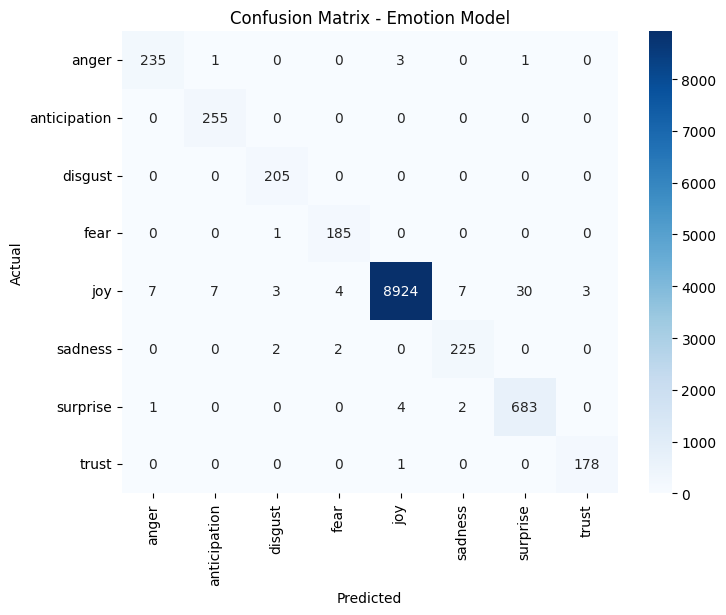

In [9]:

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Emotion Model")
plt.show()


In [3]:
import pandas as pd
from sklearn.utils import resample

# ----------------------
# 1. Load your dataset
# ----------------------
# Replace 'emotions.csv' with your actual dataset file
# Update the path to the correct location of the dataset
df = pd.read_csv("data/cleaned/emotion_clean_final_filtered.csv")

print("Before balancing:")
print(df['label'].value_counts())

# ----------------------
# 2. Balance dataset
# ----------------------
# Find the minimum class count (smallest class size)
min_class_size = df['label'].value_counts().min()

balanced_list = []

# For each class, downsample to the minimum class size
for label in df['label'].unique():
    df_class = df[df['label'] == label]
    df_class_downsampled = resample(
        df_class,
        replace=False,            # sample without replacement
        n_samples=min_class_size, # match minority class size
        random_state=42
    )
    balanced_list.append(df_class_downsampled)

# Combine back
df_balanced = pd.concat(balanced_list)

print("\nAfter balancing:")
print(df_balanced['label'].value_counts())

# ----------------------
# 3. Save new dataset
# ----------------------
df_balanced.to_csv("data/cleaned/emotions_balanced.csv", index=False)
print("\n✅ Balanced dataset saved as emotions_balanced.csv")


Before balancing:
label
surprised       3247
angry           2251
proud           2189
sad             2186
grateful        2070
lonely          2067
afraid          2035
terrified       2032
disgusted       2007
guilty          2001
anxious         2000
confident       1999
hopeful         1989
furious         1988
impressed       1979
nostalgic       1968
disappointed    1931
joyful          1923
prepared        1914
content         1868
devastated      1811
embarrassed     1807
sentimental     1740
trusting        1703
caring          1697
ashamed         1653
apprehensive    1523
faithful        1266
Name: count, dtype: int64

After balancing:
label
sentimental     1266
afraid          1266
proud           1266
faithful        1266
terrified       1266
joyful          1266
angry           1266
sad             1266
grateful        1266
prepared        1266
embarrassed     1266
lonely          1266
ashamed         1266
guilty          1266
surprised       1266
nostalgic       1266
co

Classification Report:
              precision    recall  f1-score   support

      afraid       0.23      0.21      0.21       253
       angry       0.18      0.15      0.17       253
     anxious       0.23      0.21      0.22       253
apprehensive       0.21      0.20      0.20       253
     ashamed       0.18      0.13      0.15       253
      caring       0.28      0.34      0.31       253
   confident       0.27      0.30      0.28       254
     content       0.31      0.35      0.33       254
  devastated       0.25      0.26      0.26       253
disappointed       0.22      0.20      0.21       253
   disgusted       0.38      0.41      0.39       254
 embarrassed       0.32      0.41      0.36       253
    faithful       0.29      0.27      0.28       253
     furious       0.21      0.21      0.21       253
    grateful       0.29      0.29      0.29       254
      guilty       0.27      0.26      0.26       253
     hopeful       0.22      0.26      0.24       253
   i

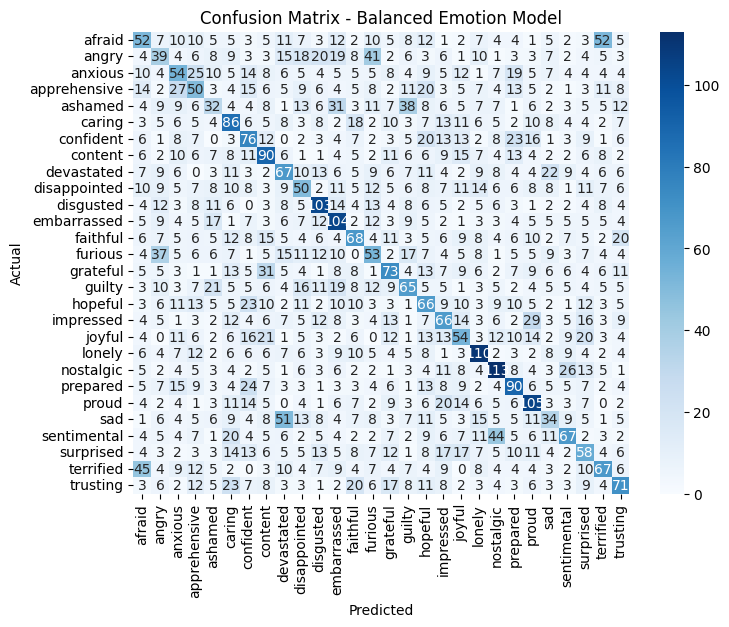


✅ Model retrained and saved (emotion_model.pkl, vectorizer.pkl)


In [6]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------
# 1. Load balanced dataset
# ----------------------
df = pd.read_csv("data/cleaned/emotions_balanced.csv")

X = df['text']
y = df['label']

# ----------------------
# 2. Train-test split
# ----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------
# 3. TF-IDF vectorization
# ----------------------
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# ----------------------
# 4. Train classifier
# ----------------------
model = LogisticRegression(max_iter=200, class_weight="balanced")
model.fit(X_train_vec, y_train)

# ----------------------
# 5. Evaluation
# ----------------------
y_pred = model.predict(X_test_vec)

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix - Balanced Emotion Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ----------------------
# 6. Save model & vectorizer
# ----------------------
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))
pickle.dump(model, open("emotion_model.pkl", "wb"))

print("\n✅ Model retrained and saved (emotion_model.pkl, vectorizer.pkl)")


Map:   0%|          | 0/43875 [00:00<?, ? examples/s]

Map:   0%|          | 0/10969 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\ankit\AppData\Local\Temp\ipykernel_25668\2780848916.py:67: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
c:\Users\ankit\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
50,3.324100
100,3.211600
150,3.088900
200,2.941000
250,2.862400
300,2.854400
350,2.761300
400,2.737100
450,2.657100
500,2.711200


c:\Users\ankit\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

      afraid       0.23      0.14      0.17       405
       angry       0.24      0.37      0.29       460
     anxious       0.35      0.33      0.34       398
apprehensive       0.27      0.13      0.18       311
     ashamed       0.26      0.07      0.12       348
      caring       0.38      0.42      0.40       331
   confident       0.33      0.39      0.36       391
     content       0.37      0.50      0.42       353
  devastated       0.35      0.19      0.25       405
disappointed       0.23      0.30      0.26       370
   disgusted       0.45      0.50      0.48       408
 embarrassed       0.41      0.52      0.46       378
    faithful       0.43      0.28      0.34       273
     furious       0.26      0.18      0.21       396
    grateful       0.39      0.33      0.36       424
      guilty       0.36      0.43      0.39       355
     hopeful       0.29      0.30      0.30       367
   impressed       0.37    

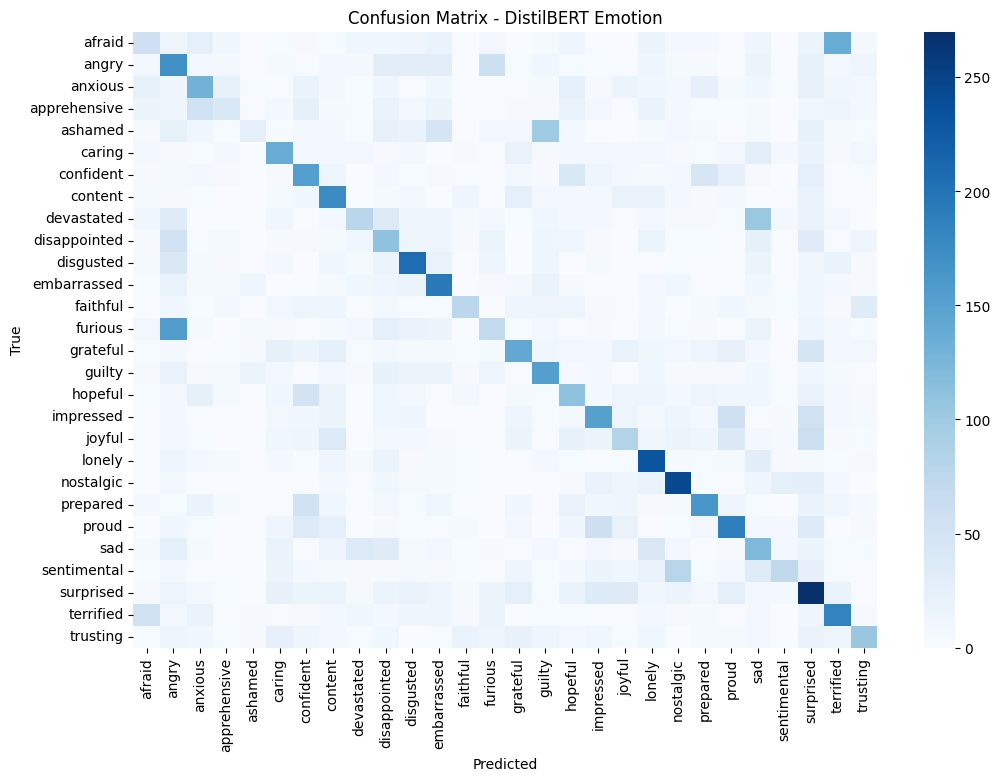

✅ Saved to models/emotion_distilbert and models/emotion_label_encoder.pkl


In [ ]:
import pandas as pd
import numpy as np
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding

# 1) Load & encode
df = pd.read_csv("data/cleaned/emotion_clean_final_filtered.csv").dropna(subset=["text","label"])
le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label_mapped"])
id2label = {i:l for i,l in enumerate(le.classes_)}
label2id = {l:i for i,l in enumerate(le.classes_)}

# 2) HF Dataset + split
dataset = Dataset.from_pandas(df[["text", "label_id"]])
dataset = dataset.train_test_split(test_size=0.2, seed=42)
train_ds, test_ds = dataset["train"], dataset["test"]

# 3) Tokenizer
tok = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
def preprocess(batch):
    # Ensure labels are included in the processed dataset
    tokenized = tok(batch["text"], truncation=True, padding=True, max_length=64)
    tokenized["labels"] = batch["label_id"]
    return tokenized
train_ds = train_ds.map(preprocess, batched=True)
test_ds = test_ds.map(preprocess, batched=True)

# 4) Model
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(le.classes_),
    id2label=id2label,
    label2id=label2id
)
collator = DataCollatorWithPadding(tokenizer=tok)

# 5) TrainingArguments (compatible with older transformers)
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=1,  # keep disk usage low
    fp16= True
)

# metrics via sklearn (works across versions)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

# 6) Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,   # eval will run at end of epoch even if not set to every epoch
    tokenizer=tok,
    data_collator=collator,
    compute_metrics=compute_metrics
)

# 7) Train
trainer.train()

# 8) Evaluate + confusion matrix
pred_out = trainer.predict(test_ds)
y_true = pred_out.label_ids
y_pred = np.argmax(pred_out.predictions, axis=1)
print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix - DistilBERT Emotion")
plt.show()

# 9) Save model + tokenizer + label encoder
model.save_pretrained("models/emotion_distilbert")
tok.save_pretrained("models/emotion_distilbert")
import joblib; joblib.dump(le, "models/emotion_label_encoder.pkl")
print("✅ Saved to models/emotion_distilbert and models/emotion_label_encoder.pkl")


✅ Final classes: ['anger' 'anticipation' 'disgust' 'fear' 'joy' 'love' 'optimism'
 'pessimism' 'sadness' 'surprise' 'trust']


Map:   0%|          | 0/43875 [00:00<?, ? examples/s]

Map:   0%|          | 0/10969 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\ankit\AppData\Local\Temp\ipykernel_27300\3660458933.py:118: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
c:\Users\ankit\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
50,2.250900
100,2.152700
150,2.029400
200,1.866900
250,1.806700
300,1.816400
350,1.765000
400,1.750900
450,1.756600
500,1.777600


c:\Users\ankit\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


              precision    recall  f1-score   support

       anger       0.49      0.51      0.50       856
anticipation       0.56      0.45      0.50       790
     disgust       0.57      0.43      0.49       408
        fear       0.55      0.58      0.56      1512
         joy       0.51      0.70      0.59      2045
        love       0.64      0.50      0.56      1102
    optimism       0.46      0.21      0.29       367
   pessimism       0.50      0.31      0.39      1108
     sadness       0.40      0.59      0.48      1527
    surprise       0.54      0.27      0.36       633
       trust       0.56      0.36      0.44       621

    accuracy                           0.51     10969
   macro avg       0.53      0.45      0.47     10969
weighted avg       0.52      0.51      0.50     10969



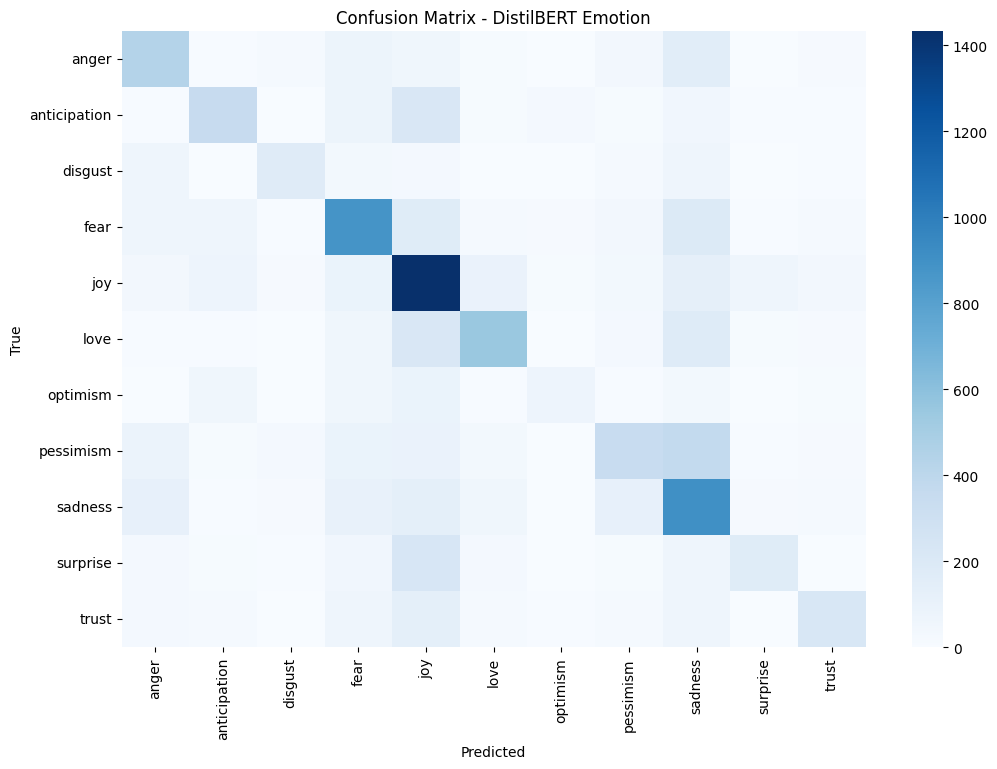

✅ Saved to models/emotion_distilbert and models/emotion_label_encoder.pkl


In [ ]:
import pandas as pd
import numpy as np
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding

df = pd.read_csv("data/cleaned/emotion_clean_final_filtered.csv").dropna(subset=["text","label"])

label_mapping = {
    "angry": "anger",
    "furious": "anger",

    "prepared": "anticipation",
    "confident": "anticipation",

    "disgusted": "disgust",

    "afraid": "fear",
    "anxious": "fear",
    "apprehensive": "fear",
    "terrified": "fear",

    "joyful": "joy",
    "content": "joy",
    "grateful": "joy",
    "proud": "joy",
    "impressed": "joy",

    "caring": "love",
    "sentimental": "love",
    "nostalgic": "love",

    "hopeful": "optimism",

    "devastated": "pessimism",
    "guilty": "pessimism",
    "ashamed": "pessimism",

    "sad": "sadness",
    "lonely": "sadness",
    "disappointed": "sadness",
    "embarrassed": "sadness",

    "surprised": "surprise",

    "trusting": "trust",
    "faithful": "trust",
}

df["label_mapped"] = df["label"].map(label_mapping)
df = df.dropna(subset=["label_mapped"])   # drop any unmapped


le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label_mapped"])
id2label = {i: l for i, l in enumerate(le.classes_)}
label2id = {l: i for i, l in enumerate(le.classes_)}

print(" Final classes:", le.classes_)


# 2) HF Dataset + split
dataset = Dataset.from_pandas(df[["text", "label_id"]])
dataset = dataset.train_test_split(test_size=0.2, seed=42)
train_ds, test_ds = dataset["train"], dataset["test"]

# 3) Tokenizer
tok = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
def preprocess(batch):
    # Ensure labels are included in the processed dataset
    tokenized = tok(batch["text"], truncation=True, padding=True, max_length=64)
    tokenized["labels"] = batch["label_id"]
    return tokenized
train_ds = train_ds.map(preprocess, batched=True)
test_ds = test_ds.map(preprocess, batched=True)

# 4) Model
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(le.classes_),
    id2label=id2label,
    label2id=label2id
)
collator = DataCollatorWithPadding(tokenizer=tok)

# 5) TrainingArguments (compatible with older transformers)
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=50,
    save_total_limit=1,  # keep disk usage low
    fp16= True
)

# metrics via sklearn (works across versions)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
        "f1_macro": f1_score(labels, preds, average="macro"),
    }

# 6) Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,   # eval will run at end of epoch even if not set to every epoch
    tokenizer=tok,
    data_collator=collator,
    compute_metrics=compute_metrics
)

# 7) Train
trainer.train()

# 8) Evaluate + confusion matrix
pred_out = trainer.predict(test_ds)
y_true = pred_out.label_ids
y_pred = np.argmax(pred_out.predictions, axis=1)
print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix - DistilBERT Emotion")
plt.show()

# 9) Save model + tokenizer + label encoder
model.save_pretrained("models/emotion_distilbert")
tok.save_pretrained("models/emotion_distilbert")
import joblib; joblib.dump(le, "models/emotion_label_encoder.pkl")
print(" Saved to models/emotion_distilbert and models/emotion_label_encoder.pkl")


In [3]:
"""
Rebuild Emotion Label Encoder
-----------------------------
This script:
✅ Loads your cleaned emotion dataset
✅ Applies your label_mapping (fine → base categories)
✅ Creates and saves a new LabelEncoder with only base emotion labels
✅ Saves it as models/emotion_label_encoder.pkl
"""

import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import joblib

# ==========================================================
# 1️⃣  Paths
# ==========================================================
dataset_path = "data/cleaned/emotion_clean_final_filtered.csv"
output_encoder_path = "models/emotion_label_encoder.pkl"

# ==========================================================
# 2️⃣  Label Mapping (same as used during training)
# ==========================================================
label_mapping = {
    "angry": "anger",
    "furious": "anger",

    "prepared": "anticipation",
    "confident": "anticipation",

    "disgusted": "disgust",

    "afraid": "fear",
    "anxious": "fear",
    "apprehensive": "fear",
    "terrified": "fear",

    "joyful": "joy",
    "content": "joy",
    "grateful": "joy",
    "proud": "joy",
    "impressed": "joy",

    "caring": "love",
    "sentimental": "love",
    "nostalgic": "love",

    "hopeful": "optimism",

    "devastated": "pessimism",
    "guilty": "pessimism",
    "ashamed": "pessimism",

    "sad": "sadness",
    "lonely": "sadness",
    "disappointed": "sadness",
    "embarrassed": "sadness",

    "surprised": "surprise",

    "trusting": "trust",
    "faithful": "trust",
}

# ==========================================================
# 3️⃣  Load Dataset
# ==========================================================
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset not found at: {dataset_path}")

df = pd.read_csv(dataset_path)
if "label" not in df.columns:
    raise KeyError("Dataset must contain a column named 'emotion'.")

# ==========================================================
# 4️⃣  Apply Mapping
# ==========================================================
df["mapped_emotion"] = df["label"].map(label_mapping)

# Remove unmapped or NaN entries
df = df.dropna(subset=["mapped_emotion"])

# ==========================================================
# 5️⃣  Fit New Label Encoder
# ==========================================================
le = LabelEncoder()
le.fit(df["mapped_emotion"].unique())

# ==========================================================
# 6️⃣  Save Encoder
# ==========================================================
os.makedirs(os.path.dirname(output_encoder_path), exist_ok=True)
joblib.dump(le, output_encoder_path)

print("✅ Label encoder rebuilt successfully!")
print("Saved to:", output_encoder_path)
print("Classes:", list(le.classes_))


✅ Label encoder rebuilt successfully!
Saved to: models/emotion_label_encoder.pkl
Classes: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'love', 'optimism', 'pessimism', 'sadness', 'surprise', 'trust']
